# Spam / Ham Classification — End-to-End ML Pipeline (Precision-Prioritised)

**Goal:** Build and evaluate multiple supervised classifiers that distinguish spam from legitimate (ham) messages, using a comprehensive text-preprocessing pipeline and class balancing. **This version prioritises Precision over F1** when ranking, tuning, and selecting models.

**Pipeline overview:**
1. Data Loading & Exploration (EDA)
2. **Comprehensive Text Preprocessing**: placeholder tokens, contraction/slang expansion, emoticons, repeated-char squeezing, lemmatization
3. **Feature Engineering** : word TF-IDF + character n-grams + hand-crafted meta-features, fused together
4. **Class Balancing** : SMOTE (50/50) applied to the *training data only*
5. Model Training : Naive Bayes, Logistic Regression, Linear SVM, Random Forest, Gradient Boosting
6. Evaluation : Accuracy, Precision, Recall, F1, ROC-AUC
7. Hyperparameter Tuning (GridSearchCV, scored on **precision**)
8. Final Model & Inference Demo

> **Why prioritise precision?** In spam filtering a *false positive*, a genuine (ham) message wrongly thrown into the spam folder  is usually far more costly than letting an occasional spam through. High precision means *when the model says "spam", it is almost always right*, so real messages are rarely lost. We therefore rank, tune, and select models on **precision** rather than F1, while still reporting recall and F1 to confirm recall does not collapse.

> **Note on balancing:** Spam is oversampled with **SMOTE to a full 50/50 balance on the training split only**. The test set is left at its natural ~13 % spam rate so that reported metrics reflect real-world performance. Balancing the whole dataset before splitting leaks information and inflates scores.

## 0 · Dependency Setup (run once)

In [3]:
import sys, subprocess

# Install any missing packages INTO THE KERNEL'S OWN ENVIRONMENT.
# Using sys.executable guarantees we install where this notebook is actually running.
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'nltk', 'scikit-learn', 'imbalanced-learn',
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'wordcloud'
])
print('Dependencies ready.')

Dependencies ready.


## **1 · Imports & Setup**

In [4]:
import os
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

NLTK_DIR = os.path.join(os.path.expanduser('~'), 'nltk_data')
os.makedirs(NLTK_DIR, exist_ok=True)
os.environ['NLTK_DATA'] = NLTK_DIR
nltk.data.path = [NLTK_DIR]

for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, download_dir=NLTK_DIR, quiet=True)

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


## **2 · Data Loading & Initial Cleaning**

#### *2.1 Data loading & Preview*

In [5]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})
print(f'Shape: {df.shape}')
df.head(10)

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


#### *2.2 Handling missing values and duplicates*

In [6]:
print('--- Missing Values ---')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after deduplication: {df.shape}')

--- Missing Values ---
label      0
message    0
dtype: int64

Duplicate rows: 403
Shape after deduplication: (5169, 2)


## **3 · Meta-Feature Construction** 

These hand-crafted features are computed from the **raw** message (before cleaning destroys case, punctuation and digits). 

In [7]:
df['char_count']   = df['message'].str.len()                                              # total number of characters in the message
df['word_count']   = df['message'].str.split().apply(len)                                 # number of whitespace-separated words
df['punct_count']  = df['message'].apply(lambda x: sum(c in string.punctuation for c in x))  # count of punctuation characters
df['upper_count']  = df['message'].apply(lambda x: sum(c.isupper() for c in x))           # count of uppercase letters
df['digit_count']  = df['message'].apply(lambda x: sum(c.isdigit() for c in x))           # count of digit characters
df['upper_ratio']  = df['upper_count'] / df['char_count'].clip(lower=1)                   # share of uppercase chars (clip avoids divide-by-zero)
df['exclam_count'] = df['message'].str.count('!')                                         # number of exclamation marks
df['has_currency'] = df['message'].str.contains(r'[£$€]').astype(int)                     # 1 if a currency symbol is present, else 0
df['has_url']      = df['message'].str.contains(r'http|www\.', case=False).astype(int)    # 1 if a URL-like pattern is present, else 0
df['has_phone']    = df['message'].str.contains(r'\d{5,}').astype(int)                    # 1 if a 5+ digit run (phone/shortcode) is present, else 0

# The hand-crafted meta-features above, grouped for reuse downstream (EDA + model input)
META_COLS = ['char_count','word_count','punct_count','upper_count','digit_count',
             'upper_ratio','exclam_count','has_currency','has_url','has_phone']

# Peek at the data with the 10 new meta-features attached (truncate message for readability)
preview = df[['label', 'message'] + META_COLS].head(10).copy()
preview['message'] = preview['message'].str.slice(0, 40) + '...'
print('--- Data with meta-features (first 10 rows) ---')
display(preview)

# Compare the mean of each meta-feature across ham vs spam (transposed for readability)
print('\n--- Mean of each meta-feature by class ---')
print(df.groupby('label')[META_COLS].mean().T.round(3))

--- Data with meta-features (first 10 rows) ---


,label,message,char_count,word_count,punct_count,upper_count,digit_count,upper_ratio,exclam_count,has_currency,has_url,has_phone
0,ham,"Go until jurong point, crazy.. Available...",111,20,9,3,0,0.027027,0,0,0,0
1,ham,Ok lar... Joking wif u oni......,29,6,6,2,0,0.068966,0,0,0,0
2,spam,Free entry in 2 a wkly comp to win FA Cu...,155,28,6,10,25,0.064516,0,0,0,1
3,ham,U dun say so early hor... U c already th...,49,11,6,2,0,0.040816,0,0,0,0
4,ham,"Nah I don't think he goes to usf, he liv...",61,13,2,2,0,0.032787,0,0,0,0
5,spam,FreeMsg Hey there darling it's been 3 we...,148,32,8,7,4,0.047297,2,1,0,0
6,ham,Even my brother is not like to speak wit...,77,16,2,2,0,0.025974,0,0,0,0
7,ham,As per your request 'Melle Melle (Oru Mi...,160,26,6,10,1,0.062500,0,0,0,0
8,spam,WINNER!! As a valued network customer yo...,158,26,6,12,19,0.075949,3,1,0,1
9,spam,Had your mobile 11 months or more? U R e...,154,29,2,14,13,0.090909,1,0,0,1



--- Mean of each meta-feature by class ---
label            ham     spam
char_count    70.459  137.891
word_count    14.135   23.681
punct_count    3.866    5.649
upper_count    3.904   15.247
digit_count    0.290   15.447
upper_ratio    0.058    0.110
exclam_count   0.175    0.694
has_currency   0.004    0.332
has_url        0.000    0.139
has_phone      0.001    0.766


## **4. Exploratory Data Analyses**

#### *4.1 Distribution of Clases*

Class distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Spam ratio: 12.63%  (imbalanced -> we will balance the training set later)


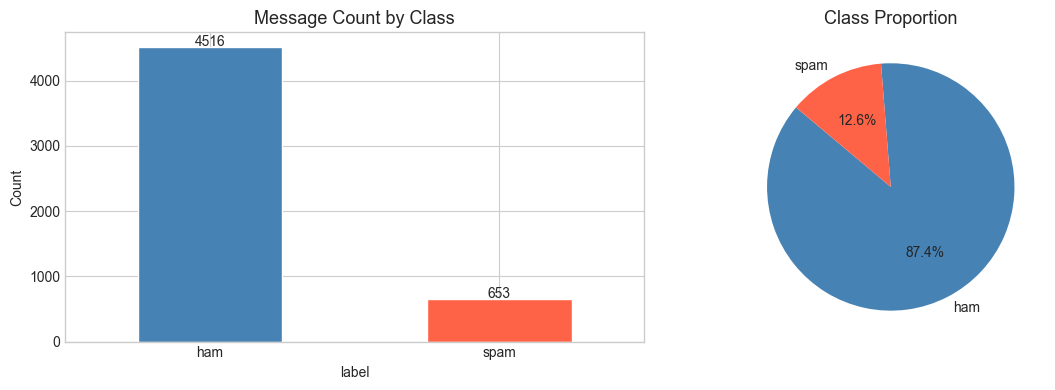

In [8]:
class_counts = df['label'].value_counts()
print('Class distribution:')
print(class_counts)
print(f'\nSpam ratio: {class_counts["spam"] / len(df):.2%}  (imbalanced -> we will balance the training set later)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white', rot=0)
axes[0].set_title('Message Count by Class', fontsize=13)
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(int(bar.get_height())), ha='center')
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['steelblue','tomato'], startangle=140)
axes[1].set_title('Class Proportion', fontsize=13)
plt.tight_layout(); plt.show()

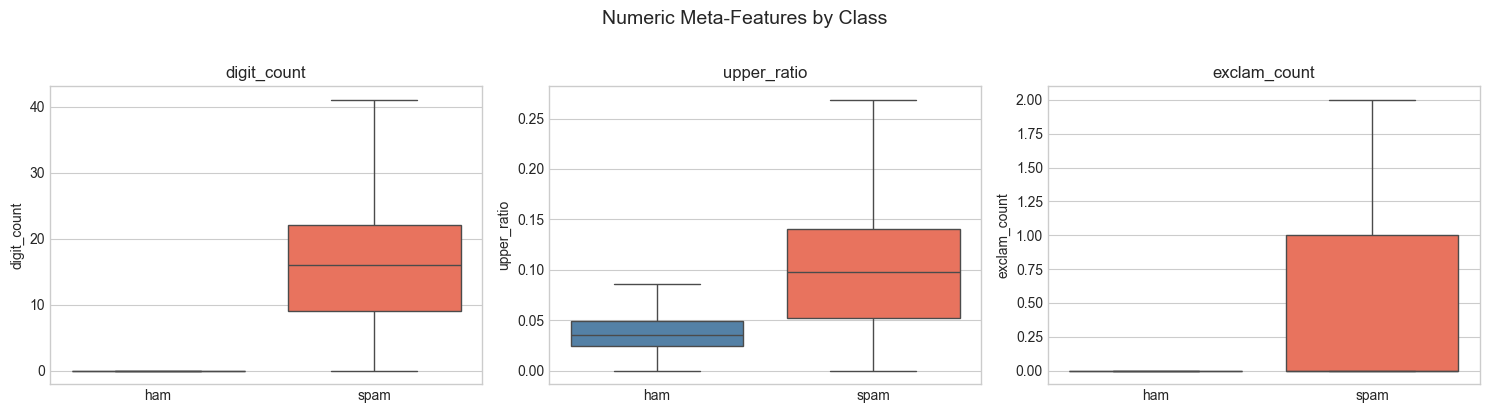

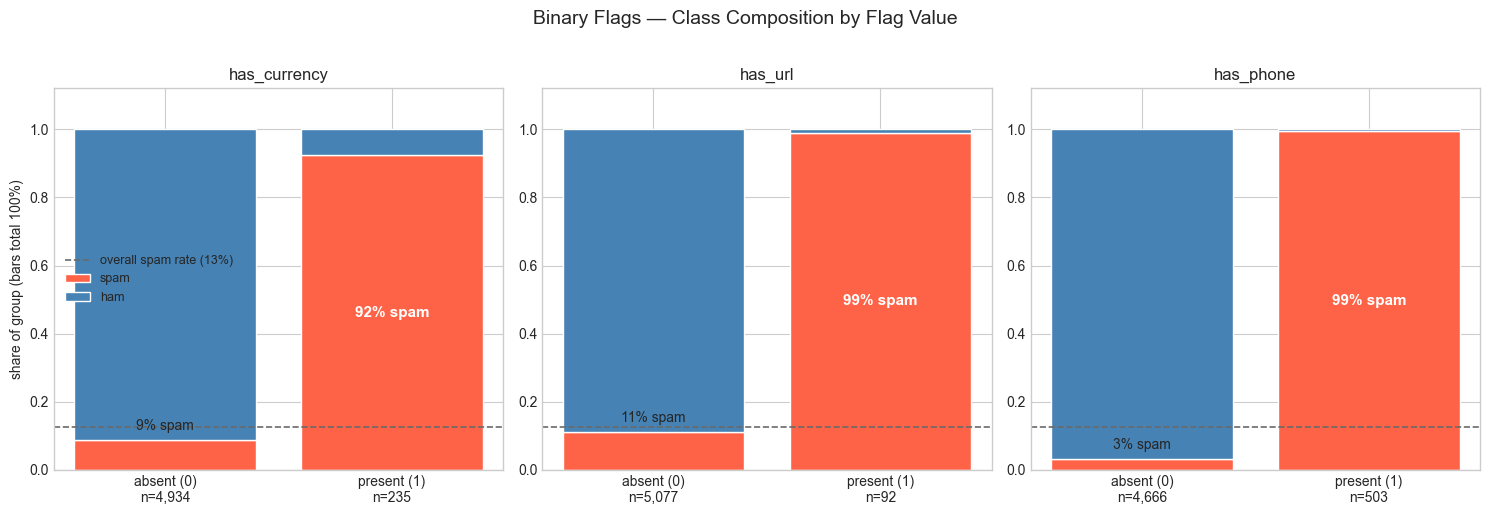

In [9]:
# EDA · Numeric Features — Distribution of continuous meta-features by class.
# Boxplots show the quartile ranges (outliers hidden for readability).
is_spam      = (df['label'] == 'spam')
overall_rate = is_spam.mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ['digit_count', 'upper_ratio', 'exclam_count']):
    sns.boxplot(data=df, x='label', y=feat, hue='label', ax=ax, legend=False,
                palette={'ham': 'steelblue', 'spam': 'tomato'}, showfliers=False)
    ax.set_title(f'{feat}', fontsize=12)
    ax.set_xlabel('')
plt.suptitle('Numeric Meta-Features by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# EDA · Binary Flags — Class composition (100% stacked bars).
# Each bar totals 100% of messages; spam (red) height shows how strongly that flag
# indicates spam. The dashed line marks the overall spam rate for reference.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for k, (ax, flag) in enumerate(zip(axes, ['has_currency', 'has_url', 'has_phone'])):
    rates      = is_spam.groupby(df[flag]).mean()      # spam share within flag=0 / flag=1
    counts     = df[flag].value_counts()
    spam_share = [rates.get(0, 0.0), rates.get(1, 0.0)]
    ham_share  = [1 - s for s in spam_share]
    xlabels    = [f'absent (0)\nn={counts.get(0, 0):,}', f'present (1)\nn={counts.get(1, 0):,}']

    ax.bar(xlabels, spam_share, color='tomato', edgecolor='white', label='spam')
    ax.bar(xlabels, ham_share, bottom=spam_share, color='steelblue', edgecolor='white', label='ham')
    for x, s in enumerate(spam_share):
        if s > 0.5:
            ax.text(x, s / 2, f'{s:.0%} spam', ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold')
        else:
            ax.text(x, s + 0.03, f'{s:.0%} spam', ha='center', fontsize=10)
    ax.axhline(overall_rate, ls='--', c='dimgray', lw=1.2,
               label=f'overall spam rate ({overall_rate:.0%})')
    ax.set_title(f'{flag}', fontsize=12)
    ax.set_ylim(0, 1.12)
    if k == 0:
        ax.set_ylabel('share of group (bars total 100%)')
        ax.legend(loc='center left', fontsize=9, framealpha=0.9)

plt.suptitle('Binary Flags — Class Composition by Flag Value', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



#### *4.2 Feature Importance*

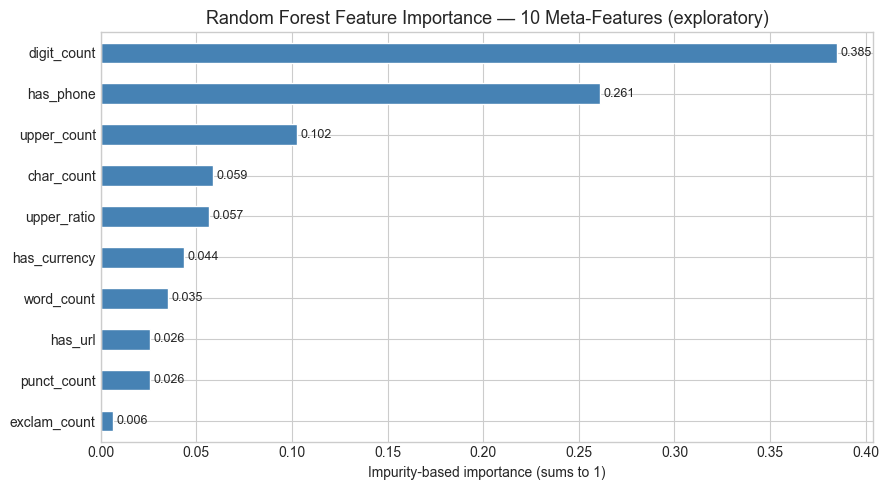

In [10]:
# EDA · Which meta-features does a Random Forest find most useful?

rf_eda = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_eda.fit(df[META_COLS], (df['label'] == 'spam').astype(int))

imp = pd.Series(rf_eda.feature_importances_, index=META_COLS).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
for y_pos, v in enumerate(imp.values):
    ax.text(v + 0.002, y_pos, f'{v:.3f}', va='center', fontsize=9)
ax.set_title('Random Forest Feature Importance — 10 Meta-Features (exploratory)', fontsize=13)
ax.set_xlabel('Impurity-based importance (sums to 1)')
plt.tight_layout()
plt.show()




#### *4.3 Word Cloud*

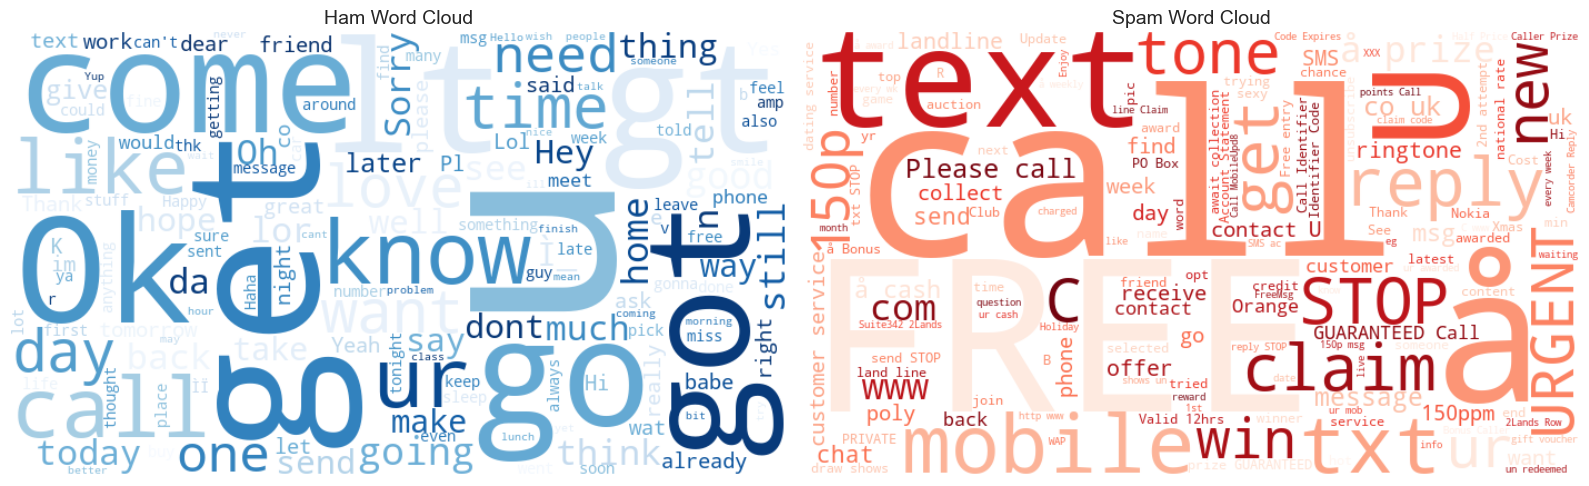

In [11]:
stop_words = set(stopwords.words('english'))
ham_text  = ' '.join(df[df['label']=='ham']['message'])
spam_text = ' '.join(df[df['label']=='spam']['message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, text, title, cmap in zip(axes, [ham_text, spam_text],
                                 ['Ham Word Cloud','Spam Word Cloud'], ['Blues','Reds']):
    wc = WordCloud(width=700, height=400, background_color='white',
                   stopwords=stop_words, colormap=cmap, max_words=150).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(title, fontsize=14)
plt.tight_layout(); plt.show()

#### *4.4 Top 20 words*

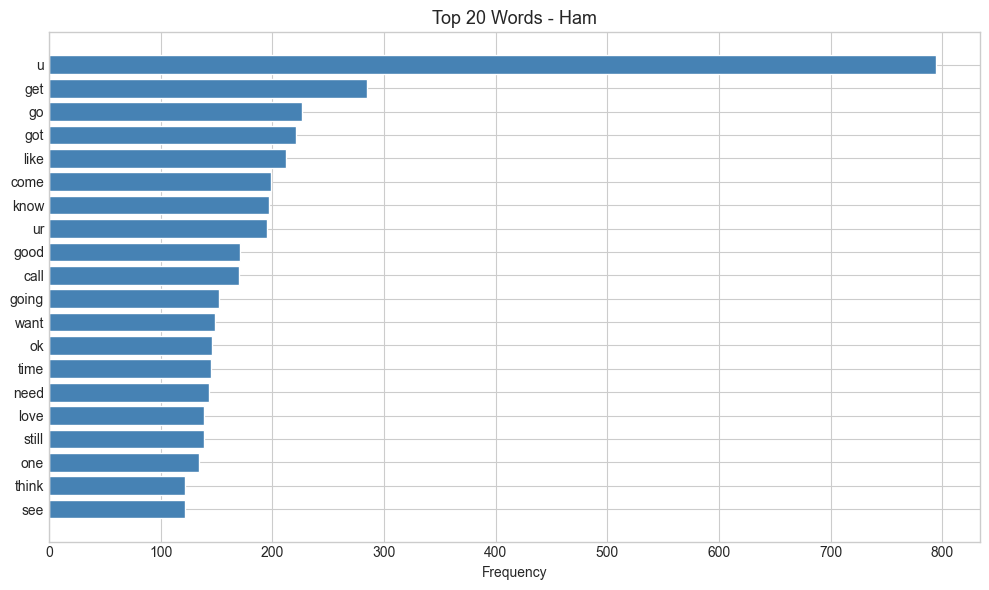

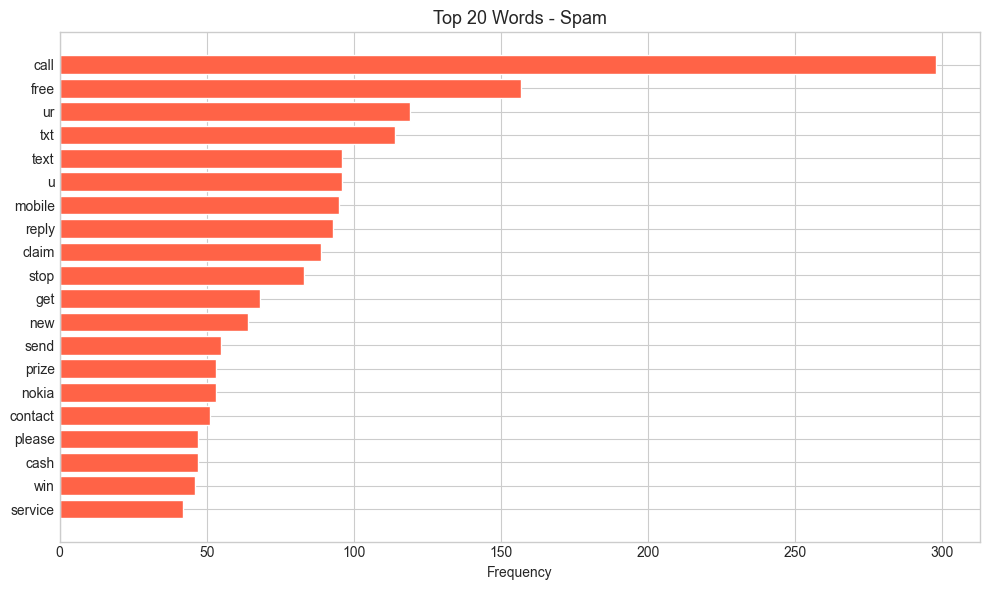

In [12]:
def top_words(texts, n=20):
    toks = [w.lower() for msg in texts for w in msg.split()
            if w.lower() not in stop_words and w.isalpha()]
    return Counter(toks).most_common(n)

fig, ax = plt.subplots(figsize=(10, 6))
words, counts = zip(*top_words(df[df['label']=='ham']['message']))
ax.barh(words[::-1], counts[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Words - Ham', fontsize=13)
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
words, counts = zip(*top_words(df[df['label']=='spam']['message']))
ax.barh(words[::-1], counts[::-1], color='tomato', edgecolor='white')
ax.set_title('Top 20 Words - Spam', fontsize=13)
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

## **5 · Comprehensive Text Preprocessing**

This applies **every** technique discussed, in a deliberate order (steps that need punctuation/case run before we strip them):

1. Lowercase
2. **Emoticon** mapping (`:)` -> `smileface`) — done before punctuation is removed
3. **Contraction** expansion (`don't` -> `do not`)
4. **Placeholder tokens**: URLs -> `url`, emails -> `email`, currency -> `money`, 5+ digit numbers -> `longnum`, other numbers -> `num`
5. **Repeated-character squeeze** (`freeeee` -> `free`)
6. Strip remaining non-alphabetic characters
7. Tokenize, **SMS slang normalization** (`u` -> `you`), stopword removal, **lemmatization**




In [13]:
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't":"do not","can't":"cannot","won't":"will not","i'm":"i am","it's":"it is",
    "you're":"you are","they're":"they are","we're":"we are","i've":"i have","you've":"you have",
    "i'll":"i will","you'll":"you will","he's":"he is","she's":"she is","that's":"that is",
    "there's":"there is","what's":"what is","let's":"let us","didn't":"did not","doesn't":"does not",
    "isn't":"is not","aren't":"are not","wasn't":"was not","weren't":"were not","haven't":"have not",
    "hasn't":"has not","wouldn't":"would not","couldn't":"could not","shouldn't":"should not",
}

SLANG = {
    "u":"you","ur":"your","r":"are","y":"why","pls":"please","plz":"please","thx":"thanks",
    "tnx":"thanks","gud":"good","gr8":"great","b4":"before","wat":"what","wen":"when","wid":"with",
    "da":"the","dis":"this","dat":"that","luv":"love","msg":"message","txt":"text","kk":"ok",
}

EMOTICONS = {
    ":)":" smileface ",":-)":" smileface ",":(":" sadface ",":-(":" sadface ",
    ":d":" grinface ",";)":" winkface ",":p":" tongueface ","<3":" heartface ",
}

def clean_text(text: str) -> str:
    text = text.lower()
    for emo, tok in EMOTICONS.items():
        text = text.replace(emo, tok)
    for c, full in CONTRACTIONS.items():
        text = text.replace(c, full)
    text = re.sub(r'http\S+|www\.\S+', ' url ',     text)
    text = re.sub(r'\S+@\S+',           ' email ',   text)
    text = re.sub(r'[£$€]',             ' money ',   text)
    text = re.sub(r'\b\d+\s?(?:p|pence|pounds?)\b', ' money ', text)
    text = re.sub(r'\b\d{5,}\b',        ' longnum ', text)
    text = re.sub(r'\b\d+\b',           ' num ',     text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)            # freeeee -> free
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    out = []
    for tok in word_tokenize(text):
        tok = SLANG.get(tok, tok)
        if tok in stop_words or len(tok) <= 1:
            continue
        out.append(lemmatizer.lemmatize(tok))
    return ' '.join(out)

df['clean_message'] = df['message'].apply(clean_text)

for _, row in df[df['label']=='spam'].head(3).iterrows():
    print(f'[RAW]   {row["message"][:110]}')
    print(f'[CLEAN] {row["clean_message"][:110]}\n')

[RAW]   Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question
[CLEAN] free entry num wkly comp win fa cup final tkts st may num text fa longnum receive entry question std text rate

[RAW]   FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb o
[CLEAN] freemsg hey darling num week word back like fun still tb ok xx std chgs send money num num rcv

[RAW]   WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 090
[CLEAN] winner valued network customer selected receivea money num prize reward claim call longnum claim code kl valid



## **6. Data Splicing & Feature Engineering**

A single `ColumnTransformer` produces and concatenates three feature blocks:

| Block | What it captures |
|---|---|
| **Word TF-IDF** (1–2 grams, `min_df`/`max_df` filtered) | normal vocabulary signal |
| **Character n-grams** (`char_wb`, 2–4) | obfuscation like `fr33` / `w1n`, sub-word patterns |
| **Meta-features** (scaled) | length, punctuation, uppercase, digits, currency/URL/phone flags |

The meta-features that were only plotted before are now part of the model input.

#### *6.1 Data Splicing*

In [14]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])      # ham=0, spam=1

X = df[['clean_message'] + META_COLS]
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train spam rate: {y_train.mean():.2%} | Test spam rate: {y_test.mean():.2%}')



Train: 4135 | Test: 1034
Train spam rate: 12.62% | Test spam rate: 12.67%


#### *6.2 Fusing 7000 Features*

The system breaks each message into three kinds of clues. First, it looks at whole words and short word‑pairs and keeps the 5,000 most useful ones; each of those becomes its own column showing how important that word is in the message. Then it does the same with tiny character fragments like ‘fr’, ‘fre’, or ‘ree’, keeping the 2,000 most common ones, because these little pieces can reveal patterns that words alone miss. Finally, it adds 10 simple facts about the message, like how long it is or whether it contains a phone number. All these clues are placed side‑by‑side to form one very wide row of numbers for each message — basically a giant fingerprint the model can learn from.

In [15]:
def build_features():
    """Fresh ColumnTransformer: word TF-IDF + char n-grams + scaled meta-features."""
    return ColumnTransformer([
        ('word_tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                       sublinear_tf=True, min_df=2, max_df=0.9), 'clean_message'),
        ('char_tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                                       max_features=2000, sublinear_tf=True, min_df=2), 'clean_message'),
        ('meta', StandardScaler(with_mean=False), META_COLS),
    ])

# Inspect the fused dimensionality
_demo = build_features().fit(X_train, y_train)
print(f'\nFused feature dimensionality: {_demo.transform(X_train).shape[1]}')


Fused feature dimensionality: 7010


#### *6.3 Preview  what each message looks like after feature engineering*

In [16]:
# ════════════════════════════════════════════════════════════════════════════
# PREVIEW · What each message looks like AFTER feature engineering
# ════════════════════════════════════════════════════════════════════════════
ct_preview = build_features().fit(X_train, y_train)
Xt         = ct_preview.transform(X_train)                       # SciPy sparse matrix
feat_names = np.array(ct_preview.get_feature_names_out())

# (1) Overall shape & sparsity ────────────────────────────────────────────────
n_cells = Xt.shape[0] * Xt.shape[1]
blocks  = pd.Series([n.split('__', 1)[0] for n in feat_names]).value_counts().to_dict()
print(f'Each message  ->  a row of {Xt.shape[1]} numbers    (per block: {blocks})')
print(f'Full matrix   :  {Xt.shape[0]} messages  x  {Xt.shape[1]} features')
print(f'Non-zero cells:  {Xt.nnz:,} / {n_cells:,}  ({Xt.nnz / n_cells:.2%})  '
      f'— the other ~{1 - Xt.nnz / n_cells:.1%} are 0.0\n')

# (2) The feature matrix up close — a few messages (rows) x active features (cols)
sample    = list(np.where(y_train.values == 1)[0][:3]) + list(np.where(y_train.values == 0)[0][:2])
used      = np.asarray(Xt[sample].sum(axis=0)).ravel()          # pick columns these rows actually use
word_cols = [j for j in np.argsort(-used) if feat_names[j].startswith('word_tfidf__')][:5]
char_cols = [j for j in np.argsort(-used) if feat_names[j].startswith('char_tfidf__')][:3]
meta_cols = [j for j, n in enumerate(feat_names) if n.startswith('meta__')]
cols      = list(word_cols) + list(char_cols) + meta_cols

excerpt = pd.DataFrame(
    Xt[sample][:, cols].toarray().round(3),
    columns=[feat_names[j].split('__', 1)[1] for j in cols],
    index=[('SPAM' if y_train.values[r] else 'ham ') + ' | ' +
           df.loc[X_train.index[r], 'clean_message'][:30] for r in sample],
)
print('(2) The feature matrix up close — 5 messages (rows) x selected features (cols).')
print('    word/char cells = TF-IDF weights · meta cells = standardized counts · 0 = feature absent')
display(excerpt)

# (3) One message fully decoded — every column it switches on ──────────────────
i   = sample[0]
row = Xt[i].toarray().ravel()
nz  = np.where(row > 0)[0]
decoded = (pd.DataFrame({'block':   [feat_names[j].split('__', 1)[0] for j in nz],
                         'feature': [feat_names[j].split('__', 1)[1] for j in nz],
                         'value':   row[nz].round(4)})
           .sort_values(['block', 'value'], ascending=[True, False]))
print(f'\n(3) ONE message decoded:  "{df.loc[X_train.index[i], "message"][:75]}"')
print(f'    It activates {len(nz)} of {Xt.shape[1]} columns (all others are 0). Top 6 per block:')
display(decoded.groupby('block').head(6).reset_index(drop=True))


Each message  ->  a row of 7010 numbers    (per block: {'word_tfidf': 5000, 'char_tfidf': 2000, 'meta': 10})
Full matrix   :  4135 messages  x  7010 features
Non-zero cells:  419,670 / 28,986,350  (1.45%)  — the other ~98.6% are 0.0

(2) The feature matrix up close — 5 messages (rows) x selected features (cols).
    word/char cells = TF-IDF weights · meta cells = standardized counts · 0 = feature absent


,cool come,receiving,fr,huh,shortly,din,din,ne,char_count,word_count,punct_count,upper_count,digit_count,upper_ratio,exclam_count,has_currency,has_url,has_phone
SPAM | num day euro kickoff kept info,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.045,2.374,2.327,0.66,1.299,1.822,0.966,1.485,0.0,0.0,3.391
SPAM | receiving week triple echo rin,0.000,0.55,0.000,0.000,0.516,0.000,0.000,0.059,1.284,1.117,0.66,0.371,0.000,0.511,1.485,0.0,0.0,0.000
SPAM | dont forget place many free re,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,2.110,1.768,0.88,0.742,1.987,0.621,0.000,0.0,0.0,3.391
ham | cool come havent wined dined,0.654,0.00,0.000,0.000,0.000,0.178,0.144,0.122,1.002,1.024,0.44,0.186,0.000,0.327,0.000,0.0,0.0,0.000
ham | huh late fr dinner,0.000,0.00,0.546,0.524,0.000,0.241,0.195,0.097,0.440,0.465,0.88,0.186,0.000,0.745,0.000,0.0,0.0,0.000



(3) ONE message decoded:  "18 days to Euro2004 kickoff! U will be kept informed of all the latest news"
    It activates 179 of 7010 columns (all others are 0). Top 6 per block:


,block,feature,value
0,char_tfidf,ro,0.2009
1,char_tfidf,da,0.1281
2,char_tfidf,su,0.1244
3,char_tfidf,inf,0.1165
4,char_tfidf,med,0.1165
5,char_tfidf,k,0.1163
6,meta,has_phone,3.3906
7,meta,char_count,2.3743
8,meta,word_count,2.3266
9,meta,digit_count,1.8217


## **7 · Class Balancing: SMOTE 50/50 (Training Data Only)**

SMOTE synthesises new minority-class (spam) samples until the **training set is balanced 50/50** (`sampling_strategy=1.0`). It runs **inside** the model pipeline, so during cross-validation it only ever sees the training folds, the held-out data is never balanced. The cell below illustrates the effect on the training split.

> Note: a full 50/50 balance maximises the model's exposure to spam, which tends to **raise recall but can lower precision** (more ham risks being flagged). Since we still select on precision, watch the precision column in the results, if precision suffers too much, lowering `SMOTE_STRATEGY` (e.g. to 0.5) is the lever to pull back.

Before SMOTE -> ham: 3613, spam: 522  (12.6% spam)
After  SMOTE -> ham: 3613, spam: 3613  (50.0% spam)


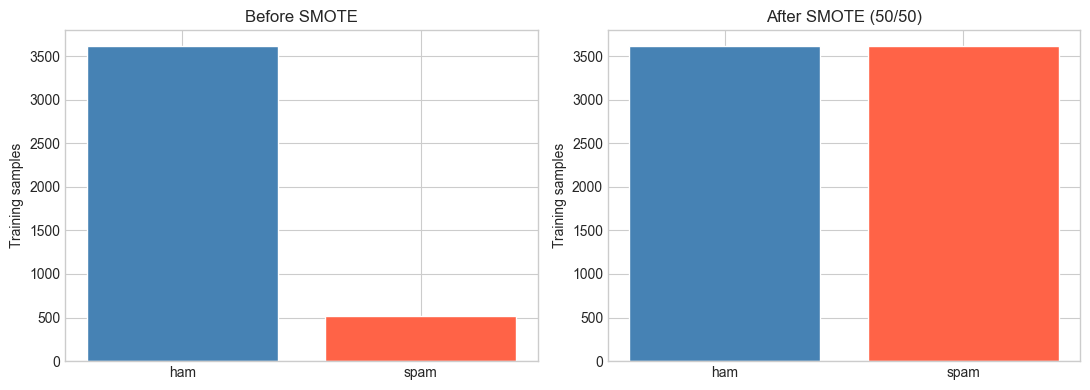

In [17]:
SMOTE_STRATEGY = 1.0   # full 50/50 balance: spam oversampled to equal the ham count

feats_train = build_features().fit_transform(X_train, y_train)
_, y_bal = SMOTE(sampling_strategy=SMOTE_STRATEGY, random_state=RANDOM_STATE).fit_resample(feats_train, y_train)

before, after = Counter(y_train), Counter(y_bal)
print(f'Before SMOTE -> ham: {before[0]}, spam: {before[1]}  ({before[1]/sum(before.values()):.1%} spam)')
print(f'After  SMOTE -> ham: {after[0]}, spam: {after[1]}  ({after[1]/sum(after.values()):.1%} spam)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in zip(axes, [before, after], ['Before SMOTE', 'After SMOTE (50/50)']):
    ax.bar(['ham','spam'], [counts[0], counts[1]], color=['steelblue','tomato'], edgecolor='white')
    ax.set_title(title); ax.set_ylabel('Training samples')
plt.tight_layout(); plt.show()

## **8 · Model Training — Baseline Comparison (Balanced Pipeline)**

Each classifier is wrapped in an `imblearn` pipeline: **features -> SMOTE -> classifier**. The test set stays untouched/imbalanced for honest evaluation. The baseline leaderboard is **sorted by Precision** to match our objective.

In [18]:
models = {
    'Multinomial NB':      MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

def make_pipeline(clf):
    return ImbPipeline([
        ('features', build_features()),
        ('balance',  SMOTE(sampling_strategy=SMOTE_STRATEGY, random_state=RANDOM_STATE)),
        ('clf',      clf),
    ])

fitted, results = {}, []
for name, clf in models.items():
    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') \
              else pipe.decision_function(X_test)
    fitted[name] = pipe
    results.append({'Model':name,
                    'Accuracy':accuracy_score(y_test, y_pred),
                    'Precision':precision_score(y_test, y_pred),
                    'Recall':recall_score(y_test, y_pred),
                    'F1':f1_score(y_test, y_pred),
                    'ROC-AUC':roc_auc_score(y_test, y_score)})

# Prioritise PRECISION: rank the leaderboard by precision (tie-break on F1)
results_df = pd.DataFrame(results).set_index('Model').sort_values(['Precision', 'F1'], ascending=False)

print('='*80)
print(' MODEL COMPARISON: ALL METRICS')
print('='*80)
display(results_df.round(4))

 MODEL COMPARISON: ALL METRICS


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.9874,1.0000,0.9008,0.9478,0.9924
Linear SVM,0.9874,0.9758,0.9237,0.9490,0.9974
Logistic Regression,0.9855,0.9531,0.9313,0.9421,0.9969
Gradient Boosting,0.9836,0.9318,0.9389,0.9354,0.9936
Multinomial NB,0.9787,0.9160,0.9160,0.9160,0.9903


#### *8.1 Evaluation of Base models (Confusion Matrices)*

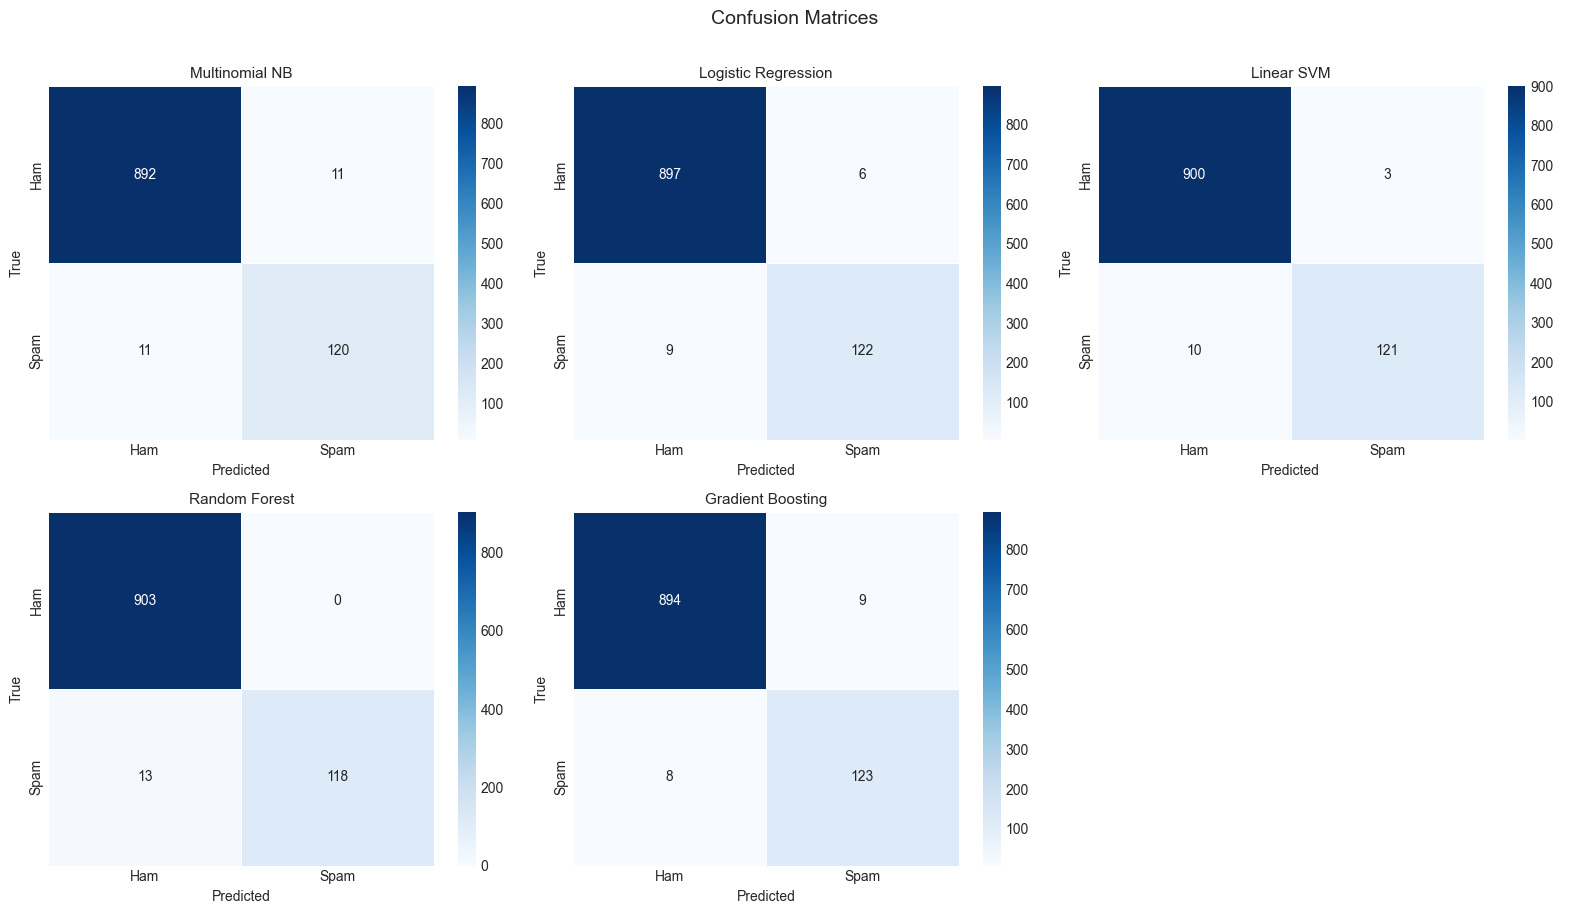

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.flatten()
for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', linewidths=0.5,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(name, fontsize=11); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
axes[-1].axis('off')
plt.suptitle('Confusion Matrices', fontsize=14, y=1.01); plt.tight_layout(); plt.show()

## **9.  Cross-Validation (5-Fold, SMOTE inside each fold)**

Because SMOTE is a pipeline step, `cross_val_score` resamples only the training portion of every fold — no leakage into validation. Scoring is **precision**, consistent with our precision-first objective.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, clf in models.items():
    scores = cross_val_score(make_pipeline(clf), X, y, cv=cv, scoring='precision', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22} Precision = {scores.mean():.4f} +/- {scores.std():.4f}')


Multinomial NB         Precision = 0.9158 +/- 0.0221
Logistic Regression    Precision = 0.9550 +/- 0.0121
Linear SVM             Precision = nan +/- nan
Random Forest          Precision = nan +/- nan
Gradient Boosting      Precision = nan +/- nan


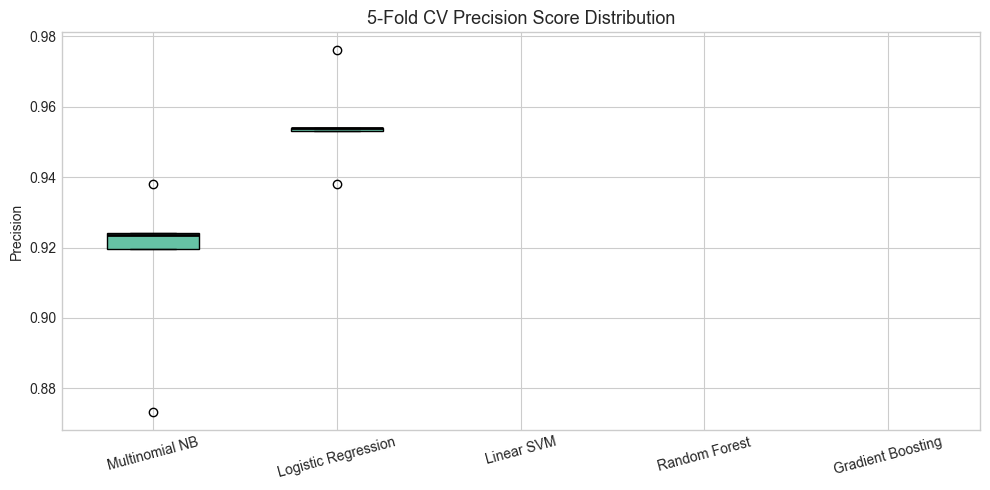

In [21]:
plt.figure(figsize=(10, 5))
plt.boxplot([cv_results[k] for k in cv_results], labels=list(cv_results.keys()),
            patch_artist=True, medianprops=dict(color='black', linewidth=2))
plt.title('5-Fold CV Precision Score Distribution', fontsize=13); plt.ylabel('Precision')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## **10 · Hyperparameter Tuning (Best Two Models)**

Random Forest and Linear SVM (the top two by cross-validated precision) are tuned with `GridSearchCV`, **scored on precision**. Note the nested parameter names address steps inside the pipeline, e.g. `features__word_tfidf__max_features`.

#### *10.1 Tuning of RF*

In [22]:
rf_grid = {
    'features__word_tfidf__max_features': [4000, 6000],
    'features__word_tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__n_estimators': [150, 250],
    'clf__max_depth': [20, None],
}
rf_gs = GridSearchCV(make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
                     rf_grid, cv=5, scoring='precision', n_jobs=-1)
rf_gs.fit(X_train, y_train)
print(f'Best RF params       : {rf_gs.best_params_}')
print(f'Best RF CV Precision : {rf_gs.best_score_:.4f}')

Best RF params       : {'clf__max_depth': 20, 'clf__n_estimators': 150, 'features__word_tfidf__max_features': 4000, 'features__word_tfidf__ngram_range': (1, 1)}
Best RF CV Precision : 0.9831


#### *10.2 Tuning of Linear SVM*

In [23]:
svm_grid = {
    'features__word_tfidf__max_features': [4000, 6000],
    'features__word_tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':                             [0.1, 0.5, 1.0, 5.0],
}
svm_gs = GridSearchCV(make_pipeline(LinearSVC(max_iter=4000, random_state=RANDOM_STATE)),
                      svm_grid, cv=5, scoring='precision', n_jobs=-1)
svm_gs.fit(X_train, y_train)
print(f'Best SVM params       : {svm_gs.best_params_}')
print(f'Best SVM CV Precision : {svm_gs.best_score_:.4f}')

Best SVM params       : {'clf__C': 5.0, 'features__word_tfidf__max_features': 6000, 'features__word_tfidf__ngram_range': (1, 2)}
Best SVM CV Precision : 0.9763


#### *10.3 Evaluation of both tuned models*

In [24]:
# Evaluate both tuned models on test set and compare all metrics
y_pred_rf  = rf_gs.predict(X_test)
y_pred_svm = svm_gs.predict(X_test)

results = {}
for name, y_pred in [('Random Forest', y_pred_rf), ('Linear SVM', y_pred_svm)]:
    y_score = rf_gs.predict_proba(X_test)[:, 1] if name == 'Random Forest' \
              else svm_gs.decision_function(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_score)
    }

results_df = pd.DataFrame(results).T
print('='*80)
print('TUNED MODEL COMPARISON: ALL METRICS')
print('='*80)
display(results_df.round(4))

best_model = rf_gs if rf_gs.best_score_ >= svm_gs.best_score_ else svm_gs
best_name  = 'Random Forest' if rf_gs.best_score_ >= svm_gs.best_score_ else 'Linear SVM'


TUNED MODEL COMPARISON: ALL METRICS


,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.9884,1.0000,0.9084,0.9520,0.9931
Linear SVM,0.9884,0.9837,0.9237,0.9528,0.9971


## **11 · Final Evaluation on Imbalanced Test Set**

**Winner: Random Forest** 

=== Final Model: Random Forest (precision-prioritised) ===
Tuned CV Precision: 0.9831
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       1.00      0.91      0.95       131

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034

  Precision  : 1.0000
  Recall     : 0.9084
  F1         : 0.9520
  Accuracy   : 0.9884


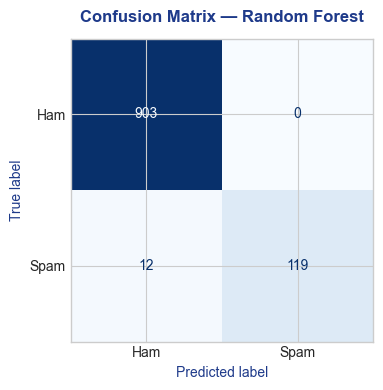

True Negatives (Ham→Ham):   903
False Positives (Ham→Spam): 0   <- the cost precision minimises
False Negatives (Spam→Ham): 12
True Positives (Spam→Spam): 119


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_final = best_model.predict(X_test)

print(f'=== Final Model: {best_name} (precision-prioritised) ===')
print(f'Tuned CV Precision: {best_model.best_score_:.4f}')
print(classification_report(y_test, y_pred_final, target_names=['Ham','Spam']))
for k, v in {'Precision':precision_score(y_test, y_pred_final),
             'Recall':recall_score(y_test, y_pred_final),
             'F1':f1_score(y_test, y_pred_final),
             'Accuracy':accuracy_score(y_test, y_pred_final)}.items():
    print(f'  {k:<11}: {v:.4f}')

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Confusion Matrix — {best_name}',
             fontsize=12, fontweight='bold', color='#1e3a8a', pad=12)
ax.set_xlabel('Predicted label', color='#1e3a8a')
ax.set_ylabel('True label', color='#1e3a8a')
plt.tight_layout()
plt.show()

print(f'True Negatives (Ham→Ham):   {tn}')
print(f'False Positives (Ham→Spam): {fp}   <- the cost precision minimises')
print(f'False Negatives (Spam→Ham): {fn}')
print(f'True Positives (Spam→Spam): {tp}')

## **12 · Inference Demo**

In [ ]:
def build_row(message: str) -> pd.DataFrame:
    """Turn a raw message into the same feature columns the model expects."""
    row = {
        'clean_message': clean_text(message),
        'char_count':   len(message),
        'word_count':   len(message.split()),
        'punct_count':  sum(c in string.punctuation for c in message),
        'upper_count':  sum(c.isupper() for c in message),
        'digit_count':  sum(c.isdigit() for c in message),
        'upper_ratio':  sum(c.isupper() for c in message) / max(len(message), 1),
        'exclam_count': message.count('!'),
        'has_currency': int(bool(re.search(r'[£$€]', message))),
        'has_url':      int(bool(re.search(r'http|www\.', message, re.I))),
        'has_phone':    int(bool(re.search(r'\d{5,}', message))),
    }
    return pd.DataFrame([row])

def predict_message(message: str) -> dict:
    row  = build_row(message)
    pred = best_model.predict(row)[0]
    label = le.inverse_transform([pred])[0]
    if hasattr(best_model, 'predict_proba'):
        conf = best_model.predict_proba(row)[0][pred]
    else:
        conf = 1 / (1 + np.exp(-abs(best_model.decision_function(row)[0])))
    return {'label': label.upper(), 'confidence': f'{conf:.2%}'}

test_messages = [
    "WINNER!! You have been selected to receive a £900 prize. Call 09061701461 now!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "FREE entry! Text WIN to 80085 for your chance to claim a holiday voucher!",
    "Can you send me the lecture notes from today please?",
    "Urgent! Your bank account has been suspended. Verify at http://secure-login.tk now",
]
print(f'{"Message":<63} {"Label":<6} Confidence')
print('-' * 84)
for msg in test_messages:
    r = predict_message(msg)
    print(f'{msg[:62]:<63} {r["label"]:<6} {r["confidence"]}')

## **13 · Summary**

| Stage | What was done |
|---|---|
| **Dataset** | ~5,170 unique messages; ~13 % spam |
| **Preprocessing** | lowercase, emoticon mapping, contraction + SMS-slang expansion, placeholder tokens (url/email/money/num), repeated-char squeeze, stopword removal, lemmatization |
| **Features** | word TF-IDF (1–2 gram) + char n-grams (2–4) + 10 scaled meta-features, fused in a `ColumnTransformer` |
| **Balancing** | **SMOTE to a full 50/50 balance on the training data only**, inside the pipeline (leakage-safe); test set left at natural rate |
| **Models** | Multinomial NB, Logistic Regression, Linear SVM, Random Forest, Gradient Boosting |
| **Selection metric** | **Precision** (prioritised over F1) — ranking, CV, and GridSearchCV all scored on precision |
| **Evaluation** | accuracy, precision, recall, F1, ROC-AUC, confusion matrices, 5-fold CV |
| **Tuning** | GridSearchCV over the best two models, **scored on precision** |

**Why prioritise precision?** A false positive (ham wrongly flagged as spam) means a real message is lost to the user's spam folder — usually worse than the occasional spam that slips through (a false negative). Optimising for precision drives the model to be *confident before it flags*, minimising false positives. We still report recall and F1 so the trade-off is visible: pushing precision up typically lets some spam through (lower recall), and the right balance depends on how costly each error is for the deployment.

**Why balance only the training set?** Oversampling the test set (or the full dataset before splitting) leaks synthetic information into evaluation and produces optimistic, unrealistic scores. Balancing only the training data lets the model learn the minority class better while metrics stay trustworthy. This version balances the training split to a full **50/50** with SMOTE; note that aggressive oversampling lifts recall but can cost some precision, so `SMOTE_STRATEGY` is exposed as a single lever if you want to dial it back.

**Spell-checking** is implemented but disabled by default — on SMS slang a generic corrector usually lowers precision; the slang dictionary is the domain-appropriate alternative.

**Further ideas:** tune the decision threshold to hit a target precision, compare `class_weight` vs. SMOTE, try `BorderlineSMOTE`/`ADASYN`, optimise an F0.5 score (precision-weighted), and fine-tune a transformer (e.g. DistilBERT).